# SO(2)-equivariant module ansatz vs. Hamiltonian Neural Network on planar Kepler dynamics

This notebook is a complete, end-to-end experiment for learning the planar Kepler/two-body vector field

$$
(q,p) \mapsto (\dot q, \dot p) = \left(p, -\mu q / \|q\|^3\right),
$$

from derivative data sampled only in a narrow angular sector, then testing over all angles.

The main model is the invariant/module-generator ansatz

$$
F_\theta(x)=\sum_{i=1}^M c_{\theta,i}(r_1(x),\ldots,r_R(x))\,m_i(x),
$$

where the scalar network learns only coefficient functions on invariant coordinates. The invariant generators and covariant module generators used here are computed by `equivariant_polynomials`; the notebook only supplies the real/complex coordinate conversion between planar vectors and the SO(2) weight basis.

The baseline is a Hamiltonian Neural Network (HNN) trained from derivative labels, following Greydanus, Dzamba, and Yosinski (NeurIPS 2019). HNNs enforce canonical Hamiltonian structure, while the module ansatz enforces SO(2)-equivariance exactly.

The experiment illustrates a common tradeoff:

- the SO(2) module ansatz extrapolates angularly because equivariance is built in;
- the HNN respects Hamiltonian structure but does not automatically impose rotational equivariance;
- the two constraints are complementary and can be combined by learning an invariant Hamiltonian.

References:

- Greydanus, S., Dzamba, M., & Yosinski, J. (2019). *Hamiltonian Neural Networks*. NeurIPS.
- The representation-theoretic generator extraction is provided by this package.

In [1]:
# This notebook is intended to be run from the repository's notebooks/ directory.
# It also works when copied elsewhere, provided the project package, PyTorch, NumPy, pandas, and matplotlib are available.

from __future__ import annotations

import os
import sys
import math
import time
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import numpy as np
import pandas as pd
import matplotlib
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Allow imports from ../src if the project is not installed in editable mode.
ROOT = Path.cwd().resolve()
for candidate in (ROOT, ROOT.parent, ROOT.parent.parent):
    src = candidate / "src"
    if src.exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))

from equivariant_polynomials import (  # noqa: E402
    IsotypicLeaf,
    SO2RepresentationTheory,
    extract_independent_generators,
    hilbert_series_so2,
)
from equivariant_polynomials.core import compute_syndromes  # noqa: E402

USE_FLOAT64 = bool(int(os.environ.get("USE_FLOAT64", "0")))
DTYPE = torch.float64 if USE_FLOAT64 else torch.float32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(DTYPE)

# Set FAST_DEV_RUN=1 in the environment to execute a quick smoke test.
FAST_DEV_RUN = bool(int(os.environ.get("FAST_DEV_RUN", "0")))

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"device={DEVICE}, dtype={DTYPE}, FAST_DEV_RUN={FAST_DEV_RUN}")

device=cpu, dtype=torch.float32, FAST_DEV_RUN=False


## 1. Thin PyTorch wrappers

The package supplies the representation-theoretic generator extraction and evaluation. This section keeps only the PyTorch wrappers needed to train from derivative labels: a coefficient MLP, a fitted affine normalizer, and the equivariant module wrapper.

In [2]:
TensorMap = Callable[[torch.Tensor], torch.Tensor]


def make_mlp(
    in_dim: int,
    out_dim: int,
    *,
    hidden_dim: int = 128,
    depth: int = 3,
    activation: type[nn.Module] = nn.Tanh,
) -> nn.Sequential:
    if depth < 1:
        raise ValueError("depth must be at least 1")
    layers: list[nn.Module] = []
    last = in_dim
    for _ in range(depth):
        layers += [nn.Linear(last, hidden_dim), activation()]
        last = hidden_dim
    layers.append(nn.Linear(last, out_dim))
    return nn.Sequential(*layers)


class Standardizer(nn.Module):
    """Fixed affine standardizer: z = (x - mean) / std."""

    def __init__(self, mean: torch.Tensor, std: torch.Tensor, eps: float = 1e-12) -> None:
        super().__init__()
        self.register_buffer("mean", mean.detach().clone())
        self.register_buffer("std", std.detach().clone().clamp_min(eps))

    @classmethod
    def fit(cls, x: torch.Tensor, eps: float = 1e-12) -> "Standardizer":
        return cls(x.mean(dim=0), x.std(dim=0).clamp_min(eps), eps=eps)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) / self.std


@dataclass(frozen=True)
class ModuleAnsatzSpec:
    invariant_map: TensorMap
    module_map: TensorMap
    invariant_dim: int
    generator_count: int
    output_dim: int


class EquivariantModuleAnsatz(nn.Module):
    """F_theta(x) = sum_i coeff_i(r(x)) m_i(x)."""

    def __init__(
        self,
        spec: ModuleAnsatzSpec,
        coefficient_net: nn.Module | None = None,
        invariant_normalizer: nn.Module | None = None,
        hidden_dim: int = 128,
        depth: int = 3,
    ) -> None:
        super().__init__()
        self.spec = spec
        self.invariant_normalizer = invariant_normalizer or nn.Identity()
        self.coefficient_net = coefficient_net or make_mlp(
            spec.invariant_dim,
            spec.generator_count,
            hidden_dim=hidden_dim,
            depth=depth,
        )

    def coefficients(self, x: torch.Tensor) -> torch.Tensor:
        invariants = self.invariant_normalizer(self.spec.invariant_map(x))
        return self.coefficient_net(invariants)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        coeffs = self.coefficients(x)
        generators = self.spec.module_map(x)
        return torch.einsum("bm,bmd->bd", coeffs, generators)

    def vector_field(self, x: torch.Tensor, *, create_graph: bool = False) -> torch.Tensor:
        return self.forward(x)

## 2. HNN baseline

The HNN is implemented in canonical coordinates $x=(q,p)$: it learns a scalar Hamiltonian $H_\theta(x)$ and returns $\dot x=J\nabla_xH_\theta(x)$, with $J=\begin{bmatrix}0&I\\-I&0\end{bmatrix}$. During training, `create_graph=True` is required because the loss depends on derivatives of the learned Hamiltonian.

In [3]:
class HamiltonianNeuralNetwork(nn.Module):
    def __init__(
        self,
        input_dim: int = 4,
        hidden_dim: int = 128,
        depth: int = 3,
        normalizer: nn.Module | None = None,
    ) -> None:
        super().__init__()
        if input_dim % 2:
            raise ValueError("canonical Hamiltonian coordinates require an even input_dim")
        self.normalizer = normalizer or nn.Identity()
        self.hamiltonian = make_mlp(input_dim, 1, hidden_dim=hidden_dim, depth=depth)
        n = input_dim // 2
        J = torch.zeros(input_dim, input_dim, dtype=DTYPE)
        J[:n, n:] = torch.eye(n, dtype=DTYPE)
        J[n:, :n] = -torch.eye(n, dtype=DTYPE)
        self.register_buffer("J", J)

    def H(self, x: torch.Tensor) -> torch.Tensor:
        return self.hamiltonian(self.normalizer(x)).squeeze(-1)

    def vector_field(self, x: torch.Tensor, *, create_graph: bool = False) -> torch.Tensor:
        with torch.enable_grad():
            x_req = x.detach().clone().requires_grad_(True)
            grad_H = torch.autograd.grad(
                self.H(x_req).sum(),
                x_req,
                create_graph=create_graph,
            )[0]
        return grad_H @ self.J.T

## 3. Kepler data and SO(2) structure

The real planar representation is complexified as two copies of weight $+1$, using $z=x+iy$, and two conjugate copies of weight $-1$. The package computes the invariant and covariant generators in this weight basis. The notebook then realifies the covariants into vector-field generators on $(\dot q,\dot p)$.

In [4]:
def J2_apply(v: torch.Tensor) -> torch.Tensor:
    """Apply J = [[0, -1], [1, 0]] to a batch of 2-vectors."""
    return torch.stack((-v[..., 1], v[..., 0]), dim=-1)


def so2_rotation(theta: torch.Tensor) -> torch.Tensor:
    """Return batched 2x2 rotation matrices."""
    c, s = torch.cos(theta), torch.sin(theta)
    return torch.stack(
        (torch.stack((c, -s), dim=-1), torch.stack((s, c), dim=-1)),
        dim=-2,
    )


def rotate_planar_pair(x: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    """Apply the diagonal SO(2) action to x=(q,p)."""
    R = so2_rotation(theta).to(device=x.device, dtype=x.dtype)
    q, p = x[..., :2], x[..., 2:]
    qR = torch.einsum("...ij,...j->...i", R, q)
    pR = torch.einsum("...ij,...j->...i", R, p)
    return torch.cat((qR, pR), dim=-1)


def positive_degree_generators(generators_by_degree: tuple[tuple[IsotypicLeaf, ...], ...]) -> tuple[IsotypicLeaf, ...]:
    return tuple(generator for degree_generators in generators_by_degree[1:] for generator in degree_generators)


class SO2KeplerFeatureEvaluator:
    """Package-generated invariant and module-generator evaluator for x=(q,p)."""

    input_irreps = (1, -1)
    input_multiplicities = (2, 2)
    trivial_irrep = 0
    covariant_irrep = 1
    modulus = 0

    def __init__(self, random_seed: int = SEED) -> None:
        self.theory = SO2RepresentationTheory()
        self.invariant_generators = positive_degree_generators(
            extract_independent_generators(
                self.theory,
                self.input_irreps,
                self.input_multiplicities,
                self.trivial_irrep,
                self.trivial_irrep,
                max_degree=2,
                probe_target=lambda dimensions, _output_dimension: dimensions,
                degree_limit=lambda degree: degree // 2,
                random_seed=random_seed,
                modulus=self.modulus,
                first_generator_degree=1,
                target_dimensions_by_degree=hilbert_series_so2(
                    self.input_irreps,
                    self.input_multiplicities,
                    self.trivial_irrep,
                    2,
                ),
            )
        )
        self.covariant_generators = positive_degree_generators(
            extract_independent_generators(
                self.theory,
                self.input_irreps,
                self.input_multiplicities,
                self.trivial_irrep,
                self.covariant_irrep,
                max_degree=1,
                probe_target=lambda dimensions, output_dimension: tuple(
                    (dimension + output_dimension - 1) // output_dimension + 2
                    if dimension
                    else 0
                    for dimension in dimensions
                ),
                degree_limit=lambda degree: degree - 1,
                random_seed=random_seed,
                modulus=self.modulus,
                target_dimensions_by_degree=hilbert_series_so2(
                    self.input_irreps,
                    self.input_multiplicities,
                    self.covariant_irrep,
                    1,
                ),
            )
        )
        self.invariant_dim = 2 * len(self.invariant_generators)
        self.generator_count = 4 * len(self.covariant_generators)
        self.output_dim = 4

    def _weight_probes(self, x: torch.Tensor) -> tuple[np.ndarray, np.ndarray]:
        x_np = x.detach().cpu().numpy()
        q, p = x_np[..., :2], x_np[..., 2:]
        plus = np.stack(
            (q[..., 0] + 1j * q[..., 1], p[..., 0] + 1j * p[..., 1]),
            axis=1,
        )[..., None].astype(np.complex128, copy=False)
        return plus, np.conjugate(plus)

    def invariant_map(self, x: torch.Tensor) -> torch.Tensor:
        values = compute_syndromes(
            self.theory,
            self.invariant_generators,
            self._weight_probes(x),
            self.modulus,
            output_dimension=1,
        )[:, 0, :]
        features = np.concatenate((values.real, values.imag), axis=-1)
        return torch.as_tensor(features, device=x.device, dtype=x.dtype)

    def module_map(self, x: torch.Tensor) -> torch.Tensor:
        values = compute_syndromes(
            self.theory,
            self.covariant_generators,
            self._weight_probes(x),
            self.modulus,
            output_dimension=1,
        )[:, 0, :]
        vectors = np.stack((values.real, values.imag), axis=-1)
        rotated_vectors = np.stack((-values.imag, values.real), axis=-1)
        generators = []
        for output_offset in (0, 2):
            for covariant_index in range(values.shape[1]):
                for block in (vectors[:, covariant_index], rotated_vectors[:, covariant_index]):
                    out = np.zeros((values.shape[0], self.output_dim), dtype=values.real.dtype)
                    out[:, output_offset : output_offset + 2] = block
                    generators.append(out)
        return torch.as_tensor(np.stack(generators, axis=1), device=x.device, dtype=x.dtype)


def kepler_vector_field(x: torch.Tensor, mu: float = 1.0, eps: float = 1e-9) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    r2 = (q * q).sum(dim=-1, keepdim=True).clamp_min(eps)
    qdot = p
    pdot = -mu * q / r2.pow(1.5)
    return torch.cat((qdot, pdot), dim=-1)


def kepler_energy(x: torch.Tensor, mu: float = 1.0, eps: float = 1e-9) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    r = torch.linalg.norm(q, dim=-1).clamp_min(eps)
    return 0.5 * (p * p).sum(dim=-1) - mu / r


def angular_momentum(x: torch.Tensor) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    return (q * J2_apply(p)).sum(dim=-1)

In [5]:
def sample_kepler_states(
    n: int,
    *,
    theta_range: tuple[float, float],
    r_range: tuple[float, float] = (0.7, 1.5),
    mu: float = 1.0,
    radial_momentum_scale: float = 0.35,
    tangential_speed_range: tuple[float, float] = (0.7, 1.3),
    device: torch.device = DEVICE,
    dtype: torch.dtype = DTYPE,
) -> torch.Tensor:
    """Sample off-circular Kepler states with angle restricted by theta_range."""
    theta = torch.empty(n, device=device, dtype=dtype).uniform_(*theta_range)
    radius = torch.empty(n, device=device, dtype=dtype).uniform_(*r_range)
    e_r = torch.stack((torch.cos(theta), torch.sin(theta)), dim=-1)
    e_t = J2_apply(e_r)
    q = radius[:, None] * e_r

    circ_speed = torch.sqrt(torch.tensor(mu, device=device, dtype=dtype) / radius)
    radial_speed = torch.empty(n, device=device, dtype=dtype).uniform_(
        -radial_momentum_scale, radial_momentum_scale
    )
    tangential_factor = torch.empty(n, device=device, dtype=dtype).uniform_(*tangential_speed_range)
    p = radial_speed[:, None] * e_r + (tangential_factor * circ_speed)[:, None] * e_t
    return torch.cat((q, p), dim=-1)


def make_dataset(n: int, theta_range: tuple[float, float]) -> tuple[torch.Tensor, torch.Tensor]:
    x = sample_kepler_states(n, theta_range=theta_range)
    y = kepler_vector_field(x)
    return x, y


if FAST_DEV_RUN:
    N_TRAIN, N_VAL, N_TEST = 128, 64, 128
    EPOCHS_MODULE, EPOCHS_HNN = 2, 2
else:
    N_TRAIN, N_VAL, N_TEST = 2048, 512, 2048
    EPOCHS_MODULE, EPOCHS_HNN = 250, 250

TRAIN_THETA_RANGE = (-math.pi / 4, math.pi / 4)
TEST_THETA_RANGE = (-math.pi, math.pi)
BATCH_SIZE = 256

x_train, y_train = make_dataset(N_TRAIN, TRAIN_THETA_RANGE)
x_val, y_val = make_dataset(N_VAL, TRAIN_THETA_RANGE)
x_test, y_test = make_dataset(N_TEST, TEST_THETA_RANGE)

print(x_train.shape, y_train.shape, x_test.shape)
print("train angle sector:", TRAIN_THETA_RANGE, "test angle sector:", TEST_THETA_RANGE)

torch.Size([2048, 4]) torch.Size([2048, 4]) torch.Size([2048, 4])
train angle sector: (-0.7853981633974483, 0.7853981633974483) test angle sector: (-3.141592653589793, 3.141592653589793)


## 4. Training and evaluation utilities

In [6]:
def make_loader(x: torch.Tensor, y: torch.Tensor, batch_size: int, shuffle: bool = True) -> DataLoader:
    return DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=shuffle)


def model_vector_field(model: nn.Module, x: torch.Tensor, *, train: bool) -> torch.Tensor:
    create_graph = train and isinstance(model, HamiltonianNeuralNetwork)
    return model.vector_field(x, create_graph=create_graph)  # type: ignore[attr-defined]


def train_vector_field_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_data: tuple[torch.Tensor, torch.Tensor],
    *,
    epochs: int,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    print_every: int = 100,
) -> pd.DataFrame:
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    x_val, y_val = val_data
    history: list[dict[str, float]] = []
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            pred = model_vector_field(model, xb, train=True)
            loss = torch.mean((pred - yb) ** 2)
            loss.backward()
            opt.step()
            total_loss += float(loss.detach()) * xb.shape[0]
            total_count += xb.shape[0]

        train_mse = total_loss / total_count
        val_mse = evaluate_derivative_mse(model, x_val, y_val, batch_size=1024)
        row = {"epoch": epoch, "train_mse": train_mse, "val_mse": val_mse}
        history.append(row)
        if epoch == 1 or epoch == epochs or epoch % print_every == 0:
            print(f"epoch {epoch:4d} | train {train_mse:.3e} | val {val_mse:.3e}")

    elapsed = time.time() - t0
    print(f"finished in {elapsed:.1f}s")
    return pd.DataFrame(history)


def evaluate_derivative_mse(
    model: nn.Module,
    x: torch.Tensor,
    y: torch.Tensor,
    *,
    batch_size: int = 1024,
) -> float:
    model.eval()
    losses = []
    counts = []
    loader = make_loader(x, y, batch_size=batch_size, shuffle=False)
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model_vector_field(model, xb, train=False)
        loss = torch.mean((pred - yb) ** 2)
        losses.append(float(loss.detach()) * xb.shape[0])
        counts.append(xb.shape[0])
    return sum(losses) / sum(counts)


def equivariance_error_so2(
    model: nn.Module,
    x: torch.Tensor,
    *,
    n_group_samples: int = 16,
    eps: float = 1e-12,
) -> float:
    """Mean relative error ||F(Rx)-R F(x)|| / ||F(x)||."""
    model.eval()
    x = x.to(DEVICE)
    errors = []
    for _ in range(n_group_samples):
        theta = torch.empty(x.shape[0], device=DEVICE, dtype=DTYPE).uniform_(-math.pi, math.pi)
        x_rot = rotate_planar_pair(x, theta)
        fx = model_vector_field(model, x, train=False)
        f_xrot = model_vector_field(model, x_rot, train=False)
        rot_fx = rotate_planar_pair(fx, theta)
        rel = torch.linalg.norm(f_xrot - rot_fx, dim=-1) / (torch.linalg.norm(fx, dim=-1) + eps)
        errors.append(float(rel.mean().detach()))
    return float(np.mean(errors))


def summarize_models(models: dict[str, nn.Module]) -> pd.DataFrame:
    rows = []
    small_n = 64 if FAST_DEV_RUN else 512
    group_samples = 2 if FAST_DEV_RUN else 8
    small_x = x_test[: min(small_n, x_test.shape[0])]
    for name, model in models.items():
        rows.append({
            "model": name,
            "train-sector derivative MSE": evaluate_derivative_mse(model, x_val, y_val),
            "all-angle derivative MSE": evaluate_derivative_mse(model, x_test, y_test),
            "SO(2) equivariance error": equivariance_error_so2(model, small_x, n_group_samples=group_samples),
            "parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        })
    return pd.DataFrame(rows).sort_values("all-angle derivative MSE")

## 5. Build and train the models

The invariant/module model is instantiated through the group-agnostic `ModuleAnsatzSpec`. For a different group, this is the only specification that should change.

In [7]:
# Fit normalizers using only training data.
so2_features = SO2KeplerFeatureEvaluator(random_seed=SEED)
invariant_normalizer = Standardizer.fit(so2_features.invariant_map(x_train)).to(DEVICE)
input_normalizer = Standardizer.fit(x_train).to(DEVICE)

so2_spec = ModuleAnsatzSpec(
    invariant_map=so2_features.invariant_map,
    module_map=so2_features.module_map,
    invariant_dim=so2_features.invariant_dim,
    generator_count=so2_features.generator_count,
    output_dim=so2_features.output_dim,
)

module_model = EquivariantModuleAnsatz(
    so2_spec,
    invariant_normalizer=invariant_normalizer,
    hidden_dim=64,
    depth=3,
).to(DEVICE)

hnn_model = HamiltonianNeuralNetwork(
    input_dim=4,
    hidden_dim=64,
    depth=3,
    normalizer=input_normalizer,
).to(DEVICE)

print("complex invariant generators:", len(so2_features.invariant_generators))
print("real invariant features:", so2_features.invariant_dim)
print("complex H_1 covariant generators:", len(so2_features.covariant_generators))
print("real output module generators:", so2_features.generator_count)
print("module ansatz parameters:", sum(p.numel() for p in module_model.parameters() if p.requires_grad))
print("HNN parameters:", sum(p.numel() for p in hnn_model.parameters() if p.requires_grad))

# The module ansatz is exactly equivariant even before training.
print("untrained module equivariance error:", equivariance_error_so2(module_model, x_test[:512], n_group_samples=4))

complex invariant generators: 4
real invariant features: 8
complex H_1 covariant generators: 2
real output module generators: 8
module ansatz parameters: 9416
HNN parameters: 8705
untrained module equivariance error: 4.58363516031568e-07


In [8]:
train_loader = make_loader(x_train, y_train, batch_size=BATCH_SIZE, shuffle=True)

print("Training SO(2) module ansatz")
hist_module = train_vector_field_model(
    module_model,
    train_loader,
    (x_val, y_val),
    epochs=EPOCHS_MODULE,
    lr=2e-3,
    print_every=max(1, EPOCHS_MODULE // 7),
)

print("\nTraining HNN baseline")
hist_hnn = train_vector_field_model(
    hnn_model,
    train_loader,
    (x_val, y_val),
    epochs=EPOCHS_HNN,
    lr=2e-3,
    print_every=max(1, EPOCHS_HNN // 7),
)

Training SO(2) module ansatz
epoch    1 | train 1.942e-01 | val 3.608e-02
epoch   35 | train 5.847e-04 | val 5.663e-04
epoch   70 | train 1.962e-04 | val 2.034e-04
epoch  105 | train 1.484e-04 | val 1.211e-04
epoch  140 | train 7.080e-05 | val 5.879e-05
epoch  175 | train 2.955e-04 | val 3.126e-04
epoch  210 | train 8.867e-05 | val 7.001e-05
epoch  245 | train 2.056e-04 | val 5.348e-05
epoch  250 | train 7.912e-05 | val 4.412e-05
finished in 14.1s

Training HNN baseline
epoch    1 | train 2.369e-01 | val 1.475e-01
epoch   35 | train 7.322e-04 | val 9.245e-04
epoch   70 | train 2.108e-04 | val 2.677e-04
epoch  105 | train 1.022e-04 | val 1.487e-04
epoch  140 | train 6.217e-05 | val 8.073e-05
epoch  175 | train 3.849e-05 | val 5.595e-05
epoch  210 | train 5.672e-05 | val 5.780e-05
epoch  245 | train 3.075e-05 | val 3.171e-05
epoch  250 | train 1.230e-04 | val 1.721e-04
finished in 11.3s


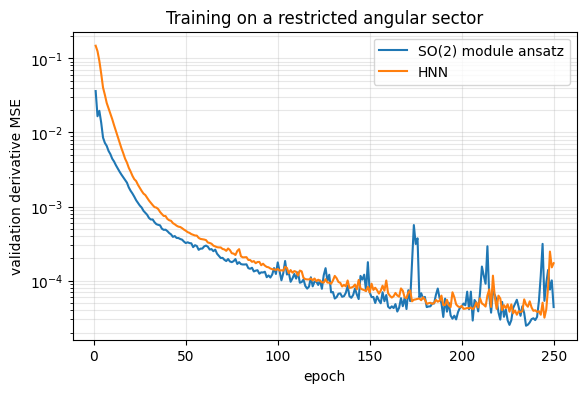

In [9]:
plt.figure(figsize=(6.5, 4))
plt.semilogy(hist_module["epoch"], hist_module["val_mse"], label="SO(2) module ansatz")
plt.semilogy(hist_hnn["epoch"], hist_hnn["val_mse"], label="HNN")
plt.xlabel("epoch")
plt.ylabel("validation derivative MSE")
plt.title("Training on a restricted angular sector")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [10]:
results = summarize_models({
    "SO(2) module ansatz": module_model,
    "HNN": hnn_model,
})
results

,model,train-sector derivative MSE,all-angle derivative MSE,SO(2) equivariance error,parameters
0,SO(2) module ansatz,0.000044,0.000041,1.563675e-07,9416
1,HNN,0.000172,0.271645,1.453860e+00,8705


## 6. Rollout evaluation

Derivative MSE is local. For dynamics learning, compare long rollouts under the learned vector fields. We integrate all models with the same RK4 scheme.

In [11]:
def rk4_step_vector_field(f: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, dt: float) -> torch.Tensor:
    k1 = f(x)
    k2 = f(x + 0.5 * dt * k1)
    k3 = f(x + 0.5 * dt * k2)
    k4 = f(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def rollout_true(x0: torch.Tensor, *, dt: float, steps: int) -> torch.Tensor:
    xs = [x0.detach().clone()]
    x = x0.detach().clone()
    for _ in range(steps):
        x = rk4_step_vector_field(lambda z: kepler_vector_field(z), x, dt).detach()
        xs.append(x)
    return torch.stack(xs, dim=0)


def rollout_model(model: nn.Module, x0: torch.Tensor, *, dt: float, steps: int) -> torch.Tensor:
    model.eval()
    xs = [x0.detach().clone()]
    x = x0.detach().clone()
    for _ in range(steps):
        x = rk4_step_vector_field(lambda z: model_vector_field(model, z, train=False), x, dt).detach()
        xs.append(x)
    return torch.stack(xs, dim=0)


def rollout_metrics(model: nn.Module, x0: torch.Tensor, *, dt: float, steps: int) -> dict[str, float | np.ndarray]:
    true_traj = rollout_true(x0, dt=dt, steps=steps)
    pred_traj = rollout_model(model, x0, dt=dt, steps=steps)
    mse_t = ((pred_traj - true_traj) ** 2).mean(dim=(1, 2)).detach().cpu().numpy()
    H = kepler_energy(pred_traj).detach().cpu().numpy()
    L = angular_momentum(pred_traj).detach().cpu().numpy()
    H0 = H[0]
    L0 = L[0]
    return {
        "trajectory_mse_t": mse_t,
        "mean_trajectory_mse": float(mse_t.mean()),
        "final_trajectory_mse": float(mse_t[-1]),
        "mean_abs_energy_drift": float(np.mean(np.abs(H - H0[None, :]))),
        "mean_abs_angular_momentum_drift": float(np.mean(np.abs(L - L0[None, :]))),
        "pred_traj": pred_traj.detach().cpu().numpy(),
        "true_traj": true_traj.detach().cpu().numpy(),
    }

In [12]:
if FAST_DEV_RUN:
    ROLLOUT_STEPS = 10
    N_ROLLOUTS = 2
else:
    ROLLOUT_STEPS = 150
    N_ROLLOUTS = 8
DT = 0.025

x0 = sample_kepler_states(N_ROLLOUTS, theta_range=TEST_THETA_RANGE).to(DEVICE)
roll_module = rollout_metrics(module_model, x0, dt=DT, steps=ROLLOUT_STEPS)
roll_hnn = rollout_metrics(hnn_model, x0, dt=DT, steps=ROLLOUT_STEPS)

rollout_table = pd.DataFrame([
    {
        "model": "SO(2) module ansatz",
        "mean rollout MSE": roll_module["mean_trajectory_mse"],
        "final rollout MSE": roll_module["final_trajectory_mse"],
        "mean |energy drift|": roll_module["mean_abs_energy_drift"],
        "mean |angular momentum drift|": roll_module["mean_abs_angular_momentum_drift"],
    },
    {
        "model": "HNN",
        "mean rollout MSE": roll_hnn["mean_trajectory_mse"],
        "final rollout MSE": roll_hnn["final_trajectory_mse"],
        "mean |energy drift|": roll_hnn["mean_abs_energy_drift"],
        "mean |angular momentum drift|": roll_hnn["mean_abs_angular_momentum_drift"],
    },
])
rollout_table

,model,mean rollout MSE,final rollout MSE,mean |energy drift|,mean |angular momentum drift|
0,SO(2) module ansatz,0.007621,0.023207,0.015773,0.011362
1,HNN,0.881778,2.996115,1.399106,1.032678


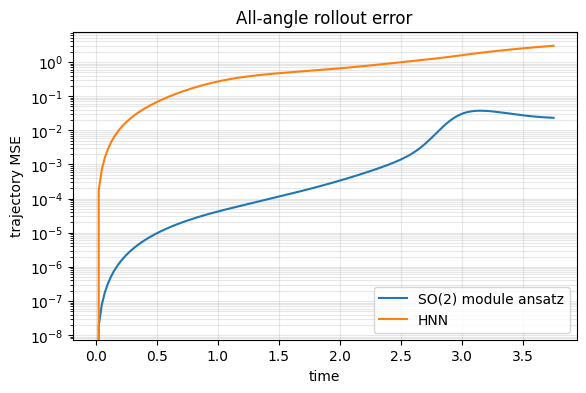

In [13]:
t = np.arange(ROLLOUT_STEPS + 1) * DT
plt.figure(figsize=(6.5, 4))
plt.semilogy(t, roll_module["trajectory_mse_t"], label="SO(2) module ansatz")
plt.semilogy(t, roll_hnn["trajectory_mse_t"], label="HNN")
plt.xlabel("time")
plt.ylabel("trajectory MSE")
plt.title("All-angle rollout error")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

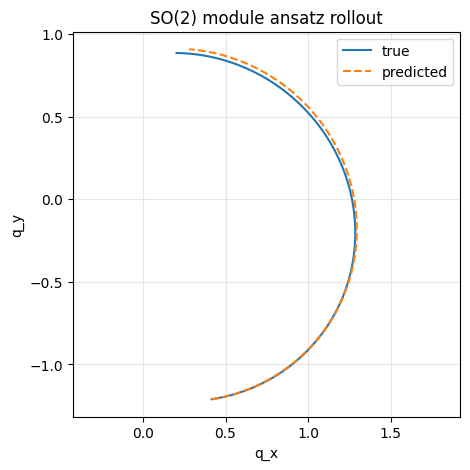

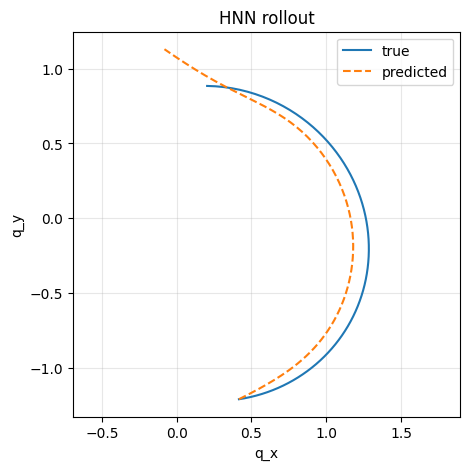

In [14]:
def plot_orbit_comparison(roll: dict[str, float | np.ndarray], title: str, index: int = 0) -> None:
    true_traj = roll["true_traj"][:, index, :]
    pred_traj = roll["pred_traj"][:, index, :]
    plt.figure(figsize=(5, 5))
    plt.plot(true_traj[:, 0], true_traj[:, 1], label="true")
    plt.plot(pred_traj[:, 0], pred_traj[:, 1], "--", label="predicted")
    plt.xlabel("q_x")
    plt.ylabel("q_y")
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_orbit_comparison(roll_module, "SO(2) module ansatz rollout")
plot_orbit_comparison(roll_hnn, "HNN rollout")

## 7. Inspect the learned coefficient functions

The coefficient table is labeled by generated covariant index rather than by hand-written polynomial formulas. For each complex package covariant $m_k$, the real module basis contains $m_k$ and $i m_k$ in the $\dot q$ output copy and again in the $\dot p$ output copy.

In [15]:
@torch.no_grad()
def inspect_coefficients(model: EquivariantModuleAnsatz, x: torch.Tensor, n: int = 8) -> pd.DataFrame:
    model.eval()
    x = x[:n].to(DEVICE)
    coeff = model.coefficients(x).detach().cpu().numpy()
    inv = model.spec.invariant_map(x).detach().cpu().numpy()

    covariant_count = coeff.shape[1] // 4
    coefficient_names = []
    for output_name in ("dq", "dp"):
        for covariant_index in range(covariant_count):
            coefficient_names += [
                f"{output_name}<-m{covariant_index}",
                f"{output_name}<-i*m{covariant_index}",
            ]

    invariant_names = [
        *(f"Re r{i}" for i in range(inv.shape[1] // 2)),
        *(f"Im r{i}" for i in range(inv.shape[1] // 2)),
    ]
    df = pd.DataFrame(coeff, columns=coefficient_names)
    for index, name in reversed(list(enumerate(invariant_names))):
        df.insert(0, name, inv[:, index])
    return df

inspect_coefficients(module_model, x_test, n=10)

,Re r0,Re r1,Re r2,Re r3,Im r0,Im r1,Im r2,Im r3,dq<-m0,dq<-i*m0,dq<-m1,dq<-i*m1,dp<-m0,dp<-i*m0,dp<-m1,dp<-i*m1
0,1.946893,0.132571,0.132571,0.542186,0.0,-1.018824,1.018824,0.0,0.075022,0.543862,-0.042186,0.015284,-0.728297,-0.043021,0.177261,-0.678991
1,2.053199,0.181839,0.181839,0.400442,0.0,-0.888325,0.888325,0.0,0.090644,0.452263,-0.047132,0.004932,-0.579517,0.022377,0.073228,-0.548709
2,1.022528,0.147754,0.147754,0.525782,0.0,-0.718189,0.718189,0.0,0.116967,0.461108,0.341481,0.031692,-0.507261,-0.132773,0.060150,0.654981
3,0.765372,0.177686,0.177686,1.003523,0.0,-0.858194,0.858194,0.0,0.144473,0.530772,0.520450,0.031922,-0.679347,-0.251381,0.081650,0.733484
4,0.996772,0.128351,0.128351,1.305805,0.0,-1.133629,1.133629,0.0,0.098169,0.653575,0.422048,0.025183,-0.999922,-0.326463,0.293559,0.041404
5,1.654840,-0.331523,-0.331523,1.041543,0.0,-1.270307,1.270307,0.0,-0.212277,0.596894,0.206236,-0.058288,-0.827219,-0.516490,0.511708,-0.609290
6,1.167657,-0.090918,-0.090918,0.675082,0.0,-0.883175,0.883175,0.0,-0.075532,0.550714,0.272266,-0.020722,-0.721481,-0.355410,0.473760,0.037712
7,1.359658,0.052461,0.052461,1.178688,0.0,-1.264856,1.264856,0.0,0.038523,0.707356,0.238612,0.015239,-1.054746,-0.324189,0.370944,-0.441519
8,2.195443,0.306697,0.306697,0.976799,0.0,-1.431937,1.431937,0.0,0.184855,0.659164,-0.022510,0.072205,-0.929987,0.051416,0.129607,-0.924522
9,1.635711,-0.278485,-0.278485,0.647771,0.0,-0.990965,0.990965,0.0,-0.188884,0.512860,0.138793,-0.061766,-0.655357,-0.391730,0.516926,-0.447644


## 8. Optional extension: orientation-sensitive SO(2) dynamics

The Kepler field is actually O(2)-equivariant, so it does not require the full orientation-sensitive SO(2) invariant $q^\top Jp$. To stress-test SO(2) rather than O(2), replace the target by

$$
\dot q=p,
\qquad
\dot p=-\mu\frac{q}{\|q\|^3}+\beta(\|q\|^2)Jp.
$$

This magnetic/gyroscopic term is SO(2)-equivariant but orientation-sensitive. The same module ansatz applies unchanged; only the data-generating vector field changes. HNNs are not designed for this noncanonical forcing unless the physics is incorporated into the Hamiltonian or symplectic structure.

In [16]:
def magnetic_kepler_vector_field(x: torch.Tensor, mu: float = 1.0, beta0: float = 0.25) -> torch.Tensor:
    q, p = x[..., :2], x[..., 2:]
    base = kepler_vector_field(x, mu=mu)
    beta = beta0 / (1.0 + (q * q).sum(dim=-1, keepdim=True))
    extra = torch.cat((torch.zeros_like(q), beta * J2_apply(p)), dim=-1)
    return base + extra

# To run the orientation-sensitive experiment, regenerate y_train/y_val/y_test using
# magnetic_kepler_vector_field and rerun the same training/evaluation cells.

## 9. Notes on the generated basis connection

The notebook now obtains its polynomial data through the package:

```python
invariant_generators = extract_independent_generators(..., output_irrep=0, max_degree=2)
covariant_generators = extract_independent_generators(..., output_irrep=1, max_degree=1)
values = compute_syndromes(theory, generators, weight_basis_inputs, modulus=0, output_dimension=1)
```

For the real Kepler state $x=(q,p)$, the only problem-specific bridge is the coordinate map from planar vectors to SO(2) weights $z=x+iy$, plus realification of each complex covariant into the two real generators $m$ and $im$. The invariant and covariant polynomials themselves are not hand-entered in the notebook.

For dynamics with known Hamiltonian structure, a parallel equivariant-Hamiltonian variant is also possible:

$$
H_\theta(x)=h_\theta(r_1(x),\ldots,r_R(x)),
\qquad
\dot x=J_{\mathrm{can}}\nabla_xH_\theta(x),
$$

which enforces both SO(2)-invariance of the Hamiltonian and canonical Hamiltonian structure.